<a href="https://colab.research.google.com/github/enzolona/farmaciaassunta/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Tue Apr 14 12:03:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code


2.10.0+cu128


## 1. What are 3 areas in industry where computer vision is currently being used?

photo enhancing in smartphones, lane recognition in traffic cameras, industry for machine failure

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

overfitting is when a model predict too much the test data, losing generality and reproducibility, this is due to using too many features, particularly when the nuber of features of the modele is similar or greater then the nuber of samples. sometimes simpler samples perform better than overcomplicated ones because they avoid overfitting

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

3 ways are: use simple models with less features, train the models against a validation sample and stop when the loss function degrades in the validation set, cross validation (kfolds)

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [4]:
#setup training data
train_data = torchvision.datasets.FashionMNIST(root="data", train= True, download=True, transform=ToTensor(), target_transform=None)
#setup test data
test_data = torchvision.datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.3MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

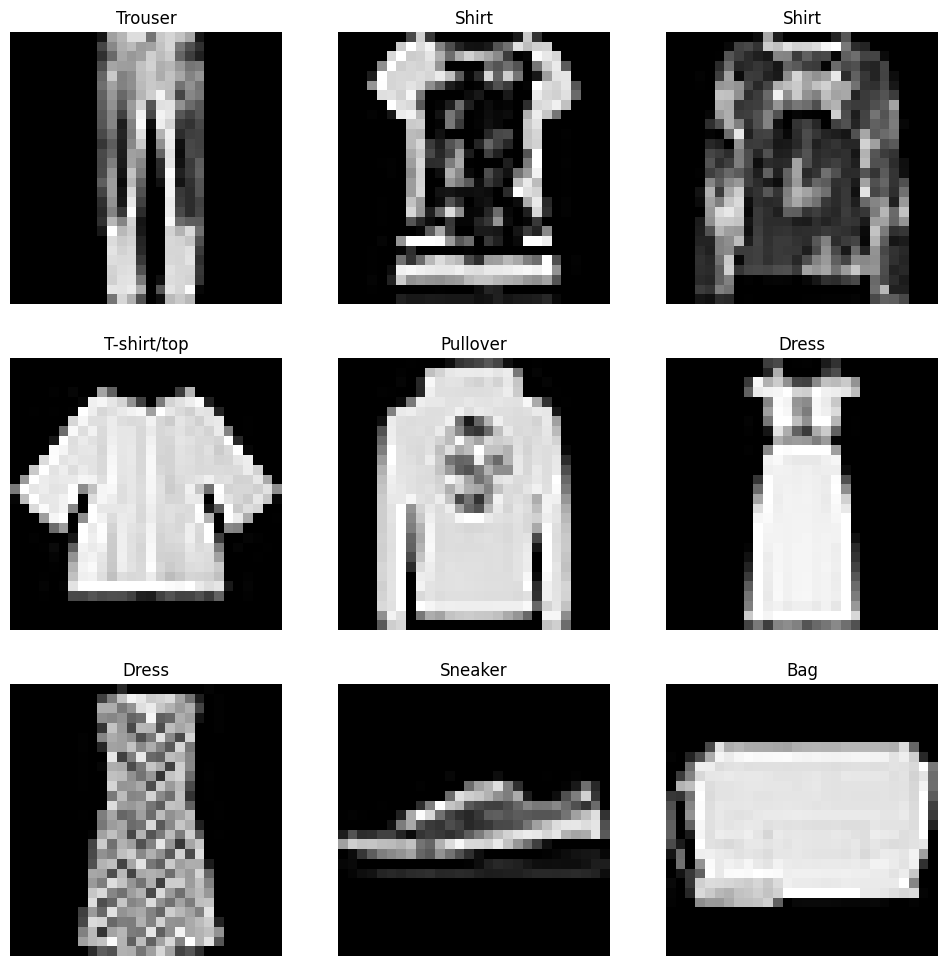

In [5]:
import matplotlib.pyplot as plt
import numpy as np
class_names = train_data.classes
np.random.seed(42)
fig = plt.figure(figsize=(12,12))
rows, cols =  3,3
for i in range(1, rows*cols + 1):
  random_idx = np.random.randint(0, len(train_data))
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader

#set the batch size parameter
BATCH_SIZE = 32

#turn the datasets into batches
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e30e70c2b40>, <torch.utils.data.dataloader.DataLoader object at 0x7e30e7f0e510>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [25]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [21]:
#functionizing training and testing loops
def train_step (model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn : torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device : torch.device = device):
  train_loss, train_acc = 0,0
  model.to(device)
  for batch, (X,y) in enumerate(data_loader):
    #send the data to the GPU
    X,y = X.to(device), y.to(device)

    #Forward pass
    y_pred = model(X)

    #Calculate the  loss function
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc}")

def test_step (model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn : torch.nn.Module, accuracy_fn, device : torch.device = device):

  test_loss, test_acc = 0,0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for X,y in data_loader:
      #send the data to the GPU
      X,y = X.to(device), y.to(device)

      #Forward pass
      y_pred = model(X)

      #Calculate the loss function
      loss = loss_fn(y_pred, y)
      test_loss += loss
      test_acc += accuracy_fn(y_true=y,
                                  y_pred=y_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"test loss: {test_loss:.5f} | test accuracy: {test_acc}")

In [13]:
from torch import nn

class FashionMNISTModel2 (nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)

    )

  def forward (self, x : torch.Tensor):
    x = self.block1(x)
    x = self.block2(x)
    x = self.classifier(x)

    return x

torch.manual_seed(42)
model_2 = FashionMNISTModel2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2


FashionMNISTModel2(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [16]:
#setting the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [17]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [15]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [22]:
from tqdm import tqdm
from helper_functions import accuracy_fn
torch.manual_seed(42)

#measure timer
from timeit import default_timer as timer
train_time_start_model_2 = timer()

epochs =  5

#train and test model
for epoch in tqdm(range(epochs)):
  print(f"Epoch:-------{epoch}")
  train_step(model_2, train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)
  test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch:-------0
Train loss: 0.32653 | Train accuracy: 88.225


 20%|██        | 1/5 [00:12<00:50, 12.67s/it]

test loss: 0.33296 | test accuracy: 87.73961661341853
Epoch:-------1
Train loss: 0.30698 | Train accuracy: 88.815


 40%|████      | 2/5 [00:24<00:37, 12.35s/it]

...

test loss: 0.30307 | test accuracy: 88.71805111821087
Epoch:-------3
Train loss: 0.28298 | Train accuracy: 89.82166666666667


 80%|████████  | 4/5 [00:49<00:12, 12.45s/it]

test loss: 0.31050 | test accuracy: 88.64816293929712
Epoch:-------4
Train loss: 0.27530 | Train accuracy: 89.98166666666667


100%|██████████| 5/5 [01:02<00:00, 12.50s/it]

test loss: 0.29314 | test accuracy: 89.54672523961662
Train time on cuda: 62.523 seconds


In [24]:
from tqdm import tqdm
from helper_functions import accuracy_fn
torch.manual_seed(42)

#measure timer
from timeit import default_timer as timer
train_time_start_model_2 = timer()

epochs =  5

#train and test model
for epoch in tqdm(range(epochs)):
  print(f"Epoch:-------{epoch}")
  train_step(model_2, train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)
  test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
c                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch:-------0
Train loss: 0.26686 | Train accuracy: 90.215


 20%|██        | 1/5 [00:38<02:33, 38.34s/it]

test loss: 0.29787 | test accuracy: 89.21725239616613
Epoch:-------1
Train loss: 0.26394 | Train accuracy: 90.36833333333334


 40%|████      | 2/5 [01:16<01:54, 38.31s/it]

...

test loss: 0.29764 | test accuracy: 89.29712460063898
Epoch:-------3
Train loss: 0.25542 | Train accuracy: 90.73666666666666


 80%|████████  | 4/5 [02:31<00:37, 37.53s/it]

test loss: 0.30457 | test accuracy: 89.1673322683706
Epoch:-------4
Train loss: 0.25117 | Train accuracy: 90.85833333333333


100%|██████████| 5/5 [03:08<00:00, 37.71s/it]

test loss: 0.29083 | test accuracy: 89.5067891373802
Train time on cpu: 188.543 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [27]:
def make_predictions (model: torch.nn.Module, data: list, device: torch.device = device):
  pred_prob = []
  model.eval()
  with torch.inference_mode():
    for smp in data:
      smp = torch.unsqueeze(smp, dim=0).to(device)

      pred_logits = model(smp)

      pred_prob = torch.softmax(input=pred_logits.squeeze(), dim=0)
  return torch.stack(pred_prob)

In [31]:
import random
random.seed(42)

test_sample = []
test_label = []

for sample, label in random.sample(list(test_data), k=9):
  test_sample.append(sample)
  test_label.append(label)

# Move model to the current device before making predictions
model_2.to(device)
pred_prob = make_predictions(model_2, test_sample)

TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?